## Anomaly detection in manufactured parts using YOLO

This project notebook aims to develop a Computer Vision program based in Deep Learning, able to detect any anomalies in manufactured parts, by making use of a **YOLO architecture**. 

The dataset used for training and testing is the MVTEC-ad, [available publicly via Kaggle](https://www.kaggle.com/datasets/ipythonx/mvtec-ad), focusing exclusively on the cable category. 

Credits to [Joel Pérez](https://github.com/joelperezd) for sharing his YOLO code with me, I've just adapted it to my application, you can check out his Github repo where he's applied this architecture for detecting fruits that have gone bad.

## 0. Importing libraries and dependencies

In [2]:
!pip install -q kagglehub ultralytics tqdm opencv-python-headless matplotlib pandas

In [34]:
from __future__ import annotations
from pathlib import Path
import os
import random
import shutil
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm.auto import tqdm
from ultralytics import YOLO
import kagglehub

import mlflow

from dotenv import load_dotenv

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

## 1. Global configuration and experiment tracking

In [35]:
# Parameter configuration

#MVTEC-ad category
CATEGORY = "cable"

# YOLO base model for classification
# yolo11n-cls (nano) = faster | yolo11s-cls / yolo11m-cls = better precision
BASE_MODEL = "yolo11n-cls.pt"

# Output folder for reformatted dataset for YOLO
OUTPUT_ROOT = Path.cwd() / f"mvtec_{CATEGORY}_yolo_cls"

# Experiment name
RUN_NAME   = f"mvtec_{CATEGORY}_cls"
TRAIN_NAME = "yolo11_ft"

# Train split ratio for 'good' images
TRAIN_RATIO = 0.85   # 85% → train, 15% → val

# Train split ratio for 'defect' images used in train/val (the rest is used in test)
DEFECT_TRAIN_FRACTION = 0.70

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# ── Dispositivo ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    ULTRA_DEVICE = 0
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    ULTRA_DEVICE = "cpu"
    print("Using CPU (GPU recommended)")

print(f"Selected category : {CATEGORY}")
print(f"Base model            : {BASE_MODEL}")
print(f"Output folder      : {OUTPUT_ROOT}")

GPU available: AMD Instinct MI210
Selected category : cable
Base model            : yolo11n-cls.pt
Output folder      : /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls


In [36]:
#Experiment tracking set up
load_dotenv()
DATABRICKS_TOKEN = os.getenv('DATABRICKS_TOKEN')
DATABRICKS_HOST = os.getenv('DATABRICKS_HOST')
MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')
MLFLOW_EXPERIMENT_ID = os.getenv('ID_YOLO')

os.environ['MLFLOW_EXPERIMENT_NAME'] = os.getenv('EXPERIMENT_YOLO')
os.environ['DATABRICKS_TOKEN'] = DATABRICKS_TOKEN
os.environ['DATABRICKS_HOST'] = DATABRICKS_HOST
os.environ['MLFLOW_TRACKING_URI'] = MLFLOW_TRACKING_URI
os.environ['MLFLOW_EXPERIMENT_ID'] = MLFLOW_EXPERIMENT_ID

mlflow.set_experiment(os.getenv('EXPERIMENT_YOLO'));

## 2. Load MVTEC-ad data from Kaggle
MVTEC anomaly detection dataset

Paul Bergmann, Michael Fauser, David Sattlegger, and Carsten Steger,
"A Comprehensive Real-World Dataset for Unsupervised Anomaly Detection",
IEEE Conference on Computer Vision and Pattern Recognition, 2019

In [37]:
mvtec_path = Path(kagglehub.dataset_download("ipythonx/mvtec-ad"))
print("Dataset path:", mvtec_path)
print("Available categories:", sorted(os.listdir(mvtec_path)))

Dataset path: /lustre/home/estudiante_65/.cache/kagglehub/datasets/ipythonx/mvtec-ad/versions/2
Available categories: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'license.txt', 'metal_nut', 'pill', 'readme.txt', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [38]:
category_path = mvtec_path / CATEGORY
assert category_path.exists(), f"Category '{CATEGORY}' not found in {mvtec_path}"

train_good_dir = category_path / "train" / "good"
test_dir       = category_path / "test"

# Training - 'good' images
train_good_imgs = [p for p in train_good_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]

# Testing - 'good' vs. 'defect' images in all folders
test_classes = sorted([d.name for d in test_dir.iterdir() if d.is_dir()])
print(f"Subfolders in test: {test_classes}")

test_good_imgs   = []
test_defect_imgs = []
for cls_dir in test_dir.iterdir():
    if not cls_dir.is_dir():
        continue
    imgs = [p for p in cls_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
    if cls_dir.name == "good":
        test_good_imgs.extend(imgs)
    else:
        test_defect_imgs.extend(imgs)

print(f"\nCategory: {CATEGORY}")
print(f"  Train → good     : {len(train_good_imgs)} images")
print(f"  Test  → good     : {len(test_good_imgs)} images")
print(f"  Test  → defect  : {len(test_defect_imgs)} images ({len(test_classes)-1} types)")

Subfolders in test: ['bent_wire', 'cable_swap', 'combined', 'cut_inner_insulation', 'cut_outer_insulation', 'good', 'missing_cable', 'missing_wire', 'poke_insulation']

Category: cable
  Train → good     : 224 images
  Test  → good     : 58 images
  Test  → defect  : 92 images (8 types)


## 3. Changing folder format required for YOLO

YOLO for classification expects:
```
dataset/
  train/
    good/      
    defect/    
  val/
    good/
    defect/
  test/
    good/
    defect/
```

**Split strategy:**
- `train/good` & `val/good` → from split `train/good` of MVTec (85% / 15%).
- `train/defect` & `val/defect` → 70% of 'defect' images in test MVTec.
- `test/` → 'good' images from test MVTec + 30% remaining of 'defect' images.

In [39]:
def split_list(items: list, ratio_a: float, seed: int = 42):
    """Randomly divides a list: ratio_a for A, the rest for B."""
    items = items.copy()
    random.Random(seed).shuffle(items)
    n_a = int(len(items) * ratio_a)
    return items[:n_a], items[n_a:]


def build_yolo_dataset(
    train_good_imgs: list[Path],
    test_good_imgs: list[Path],
    test_defect_imgs: list[Path],
    output_root: Path,
    train_ratio: float = 0.85,
    defect_train_fraction: float = 0.70,
    seed: int = 42,
):
    # Limpiar y recrear carpetas
    if output_root.exists():
        shutil.rmtree(output_root)
    for split in ["train", "val", "test"]:
        for cls in ["good", "defect"]:
            (output_root / split / cls).mkdir(parents=True, exist_ok=True)

    # Good: split train/val desde las imágenes 'good' del train de MVTec
    train_good, val_good = split_list(train_good_imgs, train_ratio, seed)

    # Defect: parte para entrenamiento (train+val), parte para test final
    defect_trainval, defect_test = split_list(test_defect_imgs, defect_train_fraction, seed)
    train_defect, val_defect     = split_list(defect_trainval,  train_ratio, seed)

    assignments = {
        ("train", "good")   : train_good,
        ("train", "defect") : train_defect,
        ("val",   "good")   : val_good,
        ("val",   "defect") : val_defect,
        ("test",  "good")   : test_good_imgs,
        ("test",  "defect") : defect_test,
    }

    print("Final distribution of dataset:")
    for (split, cls), imgs in assignments.items():
        print(f"  {split:5s} / {cls:6s} : {len(imgs):4d} images")

    # Copiar/enlazar archivos
    jobs = []
    for (split, cls), imgs in assignments.items():
        dst_dir = output_root / split / cls
        for idx, src in enumerate(imgs):
            dst = dst_dir / f"{cls}_{idx:06d}{src.suffix.lower()}"
            jobs.append((src, dst))

    def link_or_copy(src_dst):
        src, dst = src_dst
        try:
            os.link(src, dst)
        except OSError:
            shutil.copy2(src, dst)

    print(f"\nCopying {len(jobs)} files...")
    with ThreadPoolExecutor(max_workers=min(16, os.cpu_count() or 4)) as ex:
        list(tqdm(ex.map(link_or_copy, jobs), total=len(jobs), desc="Preparing dataset"))

    print(f"\nDataset ready in: {output_root}")
    return assignments


assignments = build_yolo_dataset(
    train_good_imgs       = train_good_imgs,
    test_good_imgs        = test_good_imgs,
    test_defect_imgs      = test_defect_imgs,
    output_root           = OUTPUT_ROOT,
    train_ratio           = TRAIN_RATIO,
    defect_train_fraction = DEFECT_TRAIN_FRACTION,
    seed                  = RANDOM_SEED,
)

Final distribution of dataset:
  train / good   :  190 images
  train / defect :   54 images
  val   / good   :   34 images
  val   / defect :   10 images
  test  / good   :   58 images
  test  / defect :   28 images

Copying 374 files...


Preparing dataset: 100%|██████████| 374/374 [00:00<00:00, 9369.05it/s]


Dataset ready in: /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls


## 4. Visualization of dataset samples

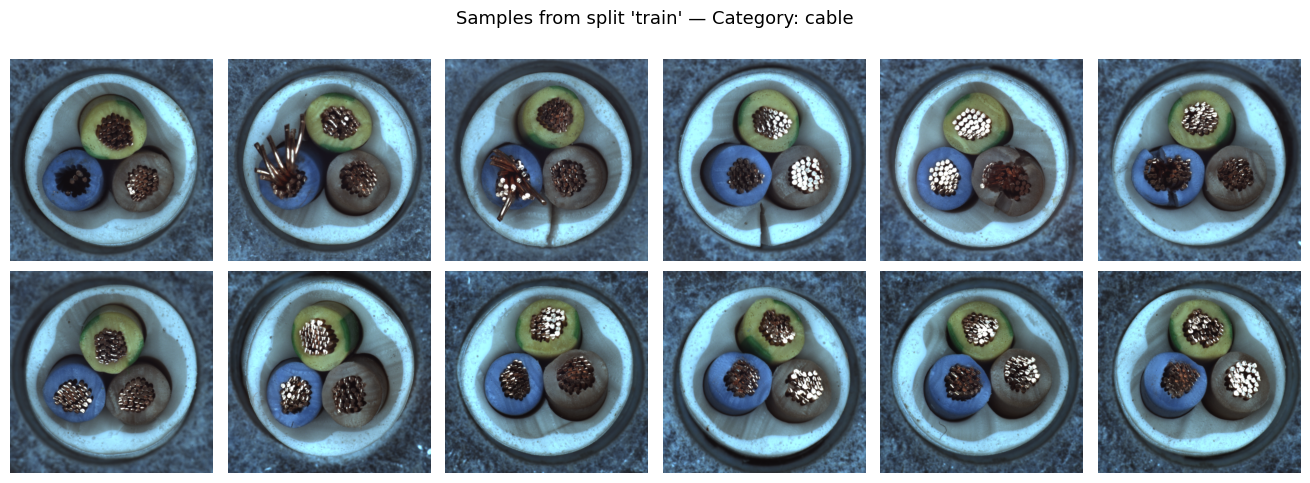

In [40]:
def show_samples(dataset_root: Path, split: str = "train", n: int = 6):
    """Shows n example images per class of given split."""
    classes = sorted([d.name for d in (dataset_root / split).iterdir() if d.is_dir()])
    fig, axes = plt.subplots(len(classes), n, figsize=(n * 2.2, len(classes) * 2.5))
    if len(classes) == 1:
        axes = [axes]
    for row, cls in enumerate(classes):
        imgs = list((dataset_root / split / cls).glob("*"))[:n]
        for col in range(n):
            ax = axes[row][col]
            ax.axis("off")
            if col < len(imgs):
                img = cv2.cvtColor(cv2.imread(str(imgs[col])), cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            if col == 0:
                ax.set_ylabel(cls, fontsize=11, fontweight="bold", rotation=90)
    plt.suptitle(f"Samples from split '{split}' — Category: {CATEGORY}", fontsize=13)
    plt.tight_layout()
    plt.show()

show_samples(OUTPUT_ROOT, split="train", n=6)

## 5. YOLO11 Model training and evaluation

In [53]:
assert OUTPUT_ROOT.exists(), f"No existe: {OUTPUT_ROOT}"

RUN_FULL_NAME = f"{RUN_NAME}_{TRAIN_NAME}"

model = YOLO(BASE_MODEL)

model.train(
    data    = str(OUTPUT_ROOT),   # Root folder with train/val/test
    task    = "classify",
    imgsz   = 224,                # 224 px es suficiente para fine-tuning rápido
    epochs  = 50,                 # Sube a 50-100 para mejores resultados
    batch   = 16,
    device  = ULTRA_DEVICE,
    project = "runs/classify",
    name    = RUN_FULL_NAME,
    pretrained    = True,
    seed          = RANDOM_SEED,
    deterministic = True,
    verbose  = True,
    workers  = 4,
    exist_ok = True,
    # Data augmentations for industrial images
    flipud   = 0.5,
    fliplr   = 0.5,
    degrees  = 15,
    translate= 0.1,
    scale    = 0.3,
)

# El objeto 'results' o 'model.trainer' tienen la ruta exacta
try:
    best_weights = Path(model.trainer.save_dir) / "weights" / "best.pt"
except (AttributeError, TypeError):
    # Fallback: Si no hay trainer activo, buscamos en la ruta estándar
    best_weights = Path("runs/classify") / RUN_FULL_NAME / "weights" / "best.pt"

# Security check on best weights
if not best_weights.exists():
    print(f"Could not find 'best.pt' in: {best_weights}")
    print("Execution folder contents:")
    !ls -R runs/classify | grep "weights" -B 2
else:
    print(f"Weights found and ready in: {best_weights}")

Ultralytics 8.4.39 🚀 Python-3.12.8 torch-2.11.0+rocm7.2 CUDA:0 (AMD Instinct MI210, 65520MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mvtec_cable_cls_yolo11_ft, nbs=64, nms=False, opse

## 6. Evaluation of trained model

In [54]:
def metrics_to_dataframe(split_name: str, metrics) -> pd.DataFrame:
    return pd.DataFrame([{
        "split"   : split_name,
        "top1_acc": round(metrics.top1, 4),
        "top5_acc": round(metrics.top5, 4),
        "fitness" : round(metrics.fitness, 4),
    }])

assert best_weights.exists(), "Critical error: Best weights file not found."

classifier_model = YOLO(str(best_weights))

val_metrics  = classifier_model.val(data=str(OUTPUT_ROOT), split="val",  imgsz=224, device=ULTRA_DEVICE)
test_metrics = classifier_model.val(data=str(OUTPUT_ROOT), split="test", imgsz=224, device=ULTRA_DEVICE)

metrics_df = pd.concat([
    metrics_to_dataframe("val",  val_metrics),
    metrics_to_dataframe("test", test_metrics),
], ignore_index=True)

print(f"\nResults — Category: {CATEGORY}")
display(metrics_df)

Ultralytics 8.4.39 🚀 Python-3.12.8 torch-2.11.0+rocm7.2 CUDA:0 (AMD Instinct MI210, 65520MiB)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls/train... found 244 images in 2 classes ✅ 
val: /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls/val... found 44 images in 2 classes ✅ 
test: /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls/test... found 86 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8688.3±897.4 MB/s, size: 1313.5 KB)
val: Scanning /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls/val... 44 images, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 26.4Mit/s 0.0s


/lustre/home/estudiante_65/defect-vision/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/lustre/home/estudiante_65/defect-vision/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.chec

               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 3.4it/s 0.9s5.0s
                   all          1          1
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /lustre/home/estudiante_65/defect-vision/runs/classify/val-5
Ultralytics 8.4.39 🚀 Python-3.12.8 torch-2.11.0+rocm7.2 CUDA:0 (AMD Instinct MI210, 65520MiB)
train: /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls/train... found 244 images in 2 classes ✅ 
val: /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls/val... found 44 images in 2 classes ✅ 
test: /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls/test... found 86 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5544.5±481.5 MB/s, size: 1301.0 KB)
test: Scanning /lustre/home/estudiante_65/defect-vision/notebooks/mvtec_cable_yolo_cls/test... 86 images, 0 corrupt: 100% ━━━━━━━━━━━━ 86/86 45.1Mit/s 0.0s


/lustre/home/estudiante_65/defect-vision/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/lustre/home/estudiante_65/defect-vision/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.chec

               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 6/6 5.5it/s 1.1s<0.1s
                   all      0.942          1
Speed: 0.0ms preprocess, 0.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /lustre/home/estudiante_65/defect-vision/runs/classify/val-6

Results — Category: cable


,split,top1_acc,top5_acc,fitness
0,val,1.0000,1.0,1.0000
1,test,0.9419,1.0,0.9709


## 7. Inference on individual images from test set

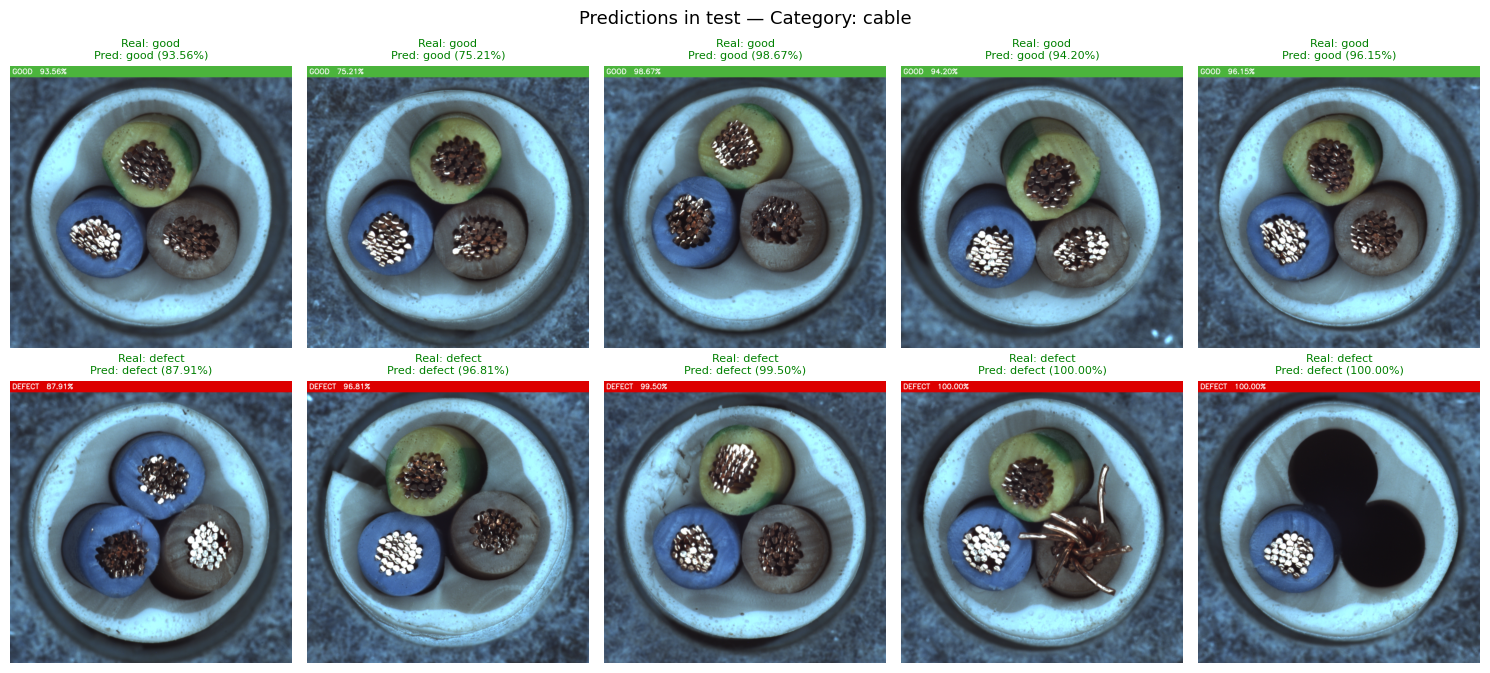

In [57]:
def classify_image(image_path: Path | str, model: YOLO, imgsz: int = 224):
    """Classifies image as 'good' or 'defect' and returns anotated image."""
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise FileNotFoundError(f"No se pudo leer: {image_path}")

    result    = model.predict(source=bgr, imgsz=imgsz, device=ULTRA_DEVICE, verbose=False)[0]
    top_idx   = int(result.probs.top1)
    label     = result.names[top_idx]
    conf      = float(result.probs.top1conf.item())

    # Anotación visual con barra de color
    color     = (60, 180, 75) if label == "good" else (0, 0, 220)   # verde / rojo
    annotated = bgr.copy()
    cv2.rectangle(annotated, (0, 0), (annotated.shape[1], 40), color, -1)
    cv2.putText(annotated, f"{label.upper()}  {conf:.2%}",
                (8, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255, 255, 255), 2)
    return annotated, label, conf


def show_test_predictions(dataset_root: Path, model: YOLO, n_per_class: int = 5):
    """Shows random predictions from test for both classes."""
    classes = ["good", "defect"]
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(n_per_class * 3, len(classes) * 3.5))
    for row, cls in enumerate(classes):
        all_imgs = list((dataset_root / "test" / cls).glob("*"))
        samples  = random.sample(all_imgs, min(n_per_class, len(all_imgs)))
        for col, img_path in enumerate(samples):
            ax = axes[row][col]
            ax.axis("off")
            try:
                annotated, pred_label, pred_conf = classify_image(img_path, model)
                ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
                correct      = pred_label == cls
                title_color  = "green" if correct else "red"
                ax.set_title(f"Real: {cls}\nPred: {pred_label} ({pred_conf:.2%})",
                             fontsize=8, color=title_color)
            except Exception as e:
                ax.set_title(str(e), fontsize=7, color="gray")
    plt.suptitle(f"Predictions in test — Category: {CATEGORY}", fontsize=13)
    plt.tight_layout()
    plt.show()


show_test_predictions(OUTPUT_ROOT, classifier_model, n_per_class=5)

## 8. Error analysis grouped by type of defect

In [58]:
# Evaluates all images on test set from MVTec, breaking down results by type of defect.

results_rows = []

for cls_dir in sorted(test_dir.iterdir()):
    if not cls_dir.is_dir():
        continue
    true_label = "good" if cls_dir.name == "good" else "defect"
    imgs = [p for p in cls_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]

    for img_path in tqdm(imgs, desc=f"Evaluating: {cls_dir.name}", leave=False):
        try:
            _, pred_label, pred_conf = classify_image(img_path, classifier_model)
            results_rows.append({
                "defect_type" : cls_dir.name,
                "true_label"  : true_label,
                "pred_label"  : pred_label,
                "confidence"  : round(pred_conf, 4),
                "correct"     : (pred_label == true_label),
            })
        except Exception:
            pass

results_df = pd.DataFrame(results_rows)

# Summary table by type of defect
summary = (
    results_df
    .groupby("defect_type")
    .agg(
        total    = ("correct", "count"),
        correct  = ("correct", "sum"),
        accuracy = ("correct", "mean"),
        avg_conf = ("confidence", "mean"),
    )
    .reset_index()
    .sort_values("accuracy", ascending=False)
)
summary["accuracy"] = summary["accuracy"].map("{:.1%}".format)
summary["avg_conf"] = summary["avg_conf"].map("{:.3f}".format)

print(f"Accuracy grouped by type of defect — Category: {CATEGORY}")
display(summary)

overall_acc = results_df["correct"].mean()
print(f"\nGlobal accuracy on original MVTec test set: {overall_acc:.2%}")

Accuracy grouped by type of defect — Category: cable


,defect_type,total,correct,accuracy,avg_conf
0,bent_wire,13,13,100.0%,0.999
2,combined,11,11,100.0%,0.974
3,cut_inner_insulation,14,14,100.0%,0.972
4,cut_outer_insulation,10,10,100.0%,0.917
6,missing_cable,12,12,100.0%,1.000
8,poke_insulation,10,10,100.0%,0.971
7,missing_wire,10,10,100.0%,0.998
5,good,58,54,93.1%,0.812
1,cable_swap,12,11,91.7%,0.849



Global accuracy on original MVTec test set: 96.67%
